# MICrONS Exploratory Data Analysis

This notebook maps out the MICrONS functional dataset and surfaces preprocessing-relevant signals before we apply dimensionality-reduction methods.

Design: see [`docs/specs/2026-04-30-microns-eda-design.md`](docs/specs/2026-04-30-microns-eda-design.md).
Companion to Federico's `analysis.ipynb`, which already runs PCA on session `7_4`. We deep-dive on the *median-neuron* session (`7_5`) here so the EDA characterizes a representative recording, not an outlier.

The notebook has four parts:

1. **Part 0** — Setup, constants, sanity check.
2. **Part 1** — Cross-session overview. Identify outlier sessions and justify the deep-dive choice.
3. **Part 2** — Deep-dive on session `7_5`: structure, stimuli, responses, behavior, preprocessing diagnostics.
4. **Part 3** — Takeaways for the dim-reduction phase.

## Part 0 — Setup

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import microns_datacleaner as mic

%load_ext autoreload
%autoreload 2

import microns_eda

### Constants

- `DATADIR` — directory containing `microns.h5`. Defaults to `../neuroscience` (Francesca's local layout: this repo cloned beside the `neuroscience/` folder). Teammates can override by setting the `MICRONS_DATADIR` environment variable.
- `DEEP_DIVE_SESSION` — `"7_5"`, the session whose neuron count is closest to the cross-session median (8,194 vs. 8,176).
- `RANDOM_SEED` — used for any sub-sampling step that needs reproducibility.
- `CORRELATION_SUBSAMPLE_N` — number of neurons randomly sub-sampled before computing the neuron × neuron correlation matrix in section 2e. **Why 2,000?** The full ~10k × 10k correlation matrix is slow to compute (~minutes) and adds no information at typical screen resolution; 2,000 keeps the heatmap legible and gives stable correlation estimates with ~40,000 timesteps per pair. **How to change it?** Edit this constant — `compute_correlation_matrix` and `plot_correlation_heatmap` accept it as a parameter. Raise it for denser views, lower for faster iteration.

In [2]:
DATADIR = Path(os.environ.get("MICRONS_DATADIR", "../neuroscience"))
DEEP_DIVE_SESSION = "7_5"
RANDOM_SEED = 42
CORRELATION_SUBSAMPLE_N = 2000
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid", context="notebook")

print("DATADIR:", DATADIR.resolve())
print("microns.h5 exists:", (DATADIR / "microns.h5").exists())

DATADIR: /Users/francesca/Desktop/neuroscience
microns.h5 exists: True


### Sanity check

Before anything heavy, verify that:

1. The `MicronsFunctionalReader` constructs without error.
2. We can list sessions through the H5 file (`h5py` fallback path).
3. We can read at least one stim type via the reader.
4. Per-trial pupil and treadmill arrays are accessible (the loaders rely on the `h5py` fallback for these).

**What we're spotting:** an environment problem (missing package, wrong path, corrupted H5) before the long EDA runs.

In [3]:
reader = microns_eda.open_dataset(DATADIR)
sessions = microns_eda.list_sessions(DATADIR)
print(f"Sessions: {len(sessions)} ({sessions[0]} ... {sessions[-1]})")

example_hash = reader.get_hashes_by_session(DEEP_DIVE_SESSION)[0]
example_type = reader.get_video_type(example_hash)
print(f"Example trial in {DEEP_DIVE_SESSION}: hash={example_hash} type={example_type}")

trial0 = microns_eda.load_trial(reader, DATADIR, DEEP_DIVE_SESSION, 0)
for k, v in trial0.items():
    if hasattr(v, "shape"):
        print(f"  {k}: shape={v.shape} dtype={v.dtype}")
    else:
        print(f"  {k}: {v!r}")

assert trial0["responses"].ndim == 2
assert trial0["pupil"].shape[0] == 4
assert trial0["treadmill"].ndim == 2
print("\nsanity check passed")

Sessions: 14 (4_7 ... 9_6)
Example trial in 7_5: hash=YLuStB2eXkgOS+Cescsy type=Monet2
  responses: shape=(8194, 113) dtype=float32
  pupil: shape=(4, 113) dtype=float32
  treadmill: shape=(113, 1) dtype=float32
  stim_times: shape=(113,) dtype=float32
  stim_type: 'Monet2'
  condition_hash: 'YLuStB2eXkgOS+Cescsy'

sanity check passed


**Expected output above:** 14 sessions; an example hash with stim type `Clip`, `Monet2`, `Trippy`, or `Unknown`; and per-trial arrays whose shapes match the spec (`responses`: `(n_neurons, n_frames)`; `pupil`: `(4, n_frames)`; `treadmill`: `(n_frames, 1)`).

## Part 1 — Cross-session overview

Before deep-diving into one session, sanity-check that the 14 sessions are structurally comparable. For each diagnostic below: *what we compute → what an outlier looks like → what it means.*

This part is the slow one — building the summary table streams every session once.

### 1.1 Sessions summary table

**What we compute:** per session, neuron count, V1/AL/LM/RL counts, trial count, stim type counts, median per-neuron mean and variance, mean pupil diameter, mean treadmill speed, median trial duration.

**What we're spotting:** sessions that don't fit the template (e.g. trial count ≠ 464). They should be excluded.

In [4]:
summary_df = microns_eda.summarize_all_sessions(reader, DATADIR)
summary_df

,n_neurons,n_AL,n_LM,n_RL,n_V1,n_trials,n_Clip,n_Monet2,n_Trippy,n_Unknown,median_per_neuron_mean,median_per_neuron_var,mean_pupil_diameter,mean_treadmill_speed,median_trial_duration
session,,,,,,,,,,,,,,,
4_7,7493,387,983,811,5312,464,384,40,40,0,1.927273,57.060406,51.761351,-0.307408,75
5_6,8592,468,1158,952,6014,464,384,40,40,0,1.070414,21.085900,50.644660,0.005755,75
5_7,8138,403,1066,892,5777,464,384,40,40,0,1.179385,24.721541,31.198829,0.004712,75
6_2,8158,317,978,861,6002,464,384,40,40,0,1.343133,29.670646,34.129890,-0.000642,75
6_4,8221,317,1027,878,5999,464,384,40,40,0,1.187854,26.889683,49.304396,0.003137,75
6_6,7971,287,979,800,5905,464,384,40,40,0,1.228362,28.084067,36.394956,0.008749,75
6_7,7887,305,960,814,5808,464,384,40,40,0,1.406358,33.926815,33.323196,-0.140653,75
7_3,8618,324,1135,850,6309,464,384,40,40,0,1.005361,17.202583,38.207591,-0.000129,75
7_4,11201,575,1534,1367,7725,464,384,40,40,0,0.886731,14.375246,47.920270,-0.048380,75


**Interpretation:**

- **Structurally, the sessions are very consistent.** All 14 have exactly 464 trials, the same stimulus breakdown (384 Clip + 40 Monet2 + 40 Trippy, no Unknown), and the same median trial duration of 75 frames. At the dataset's ~7.5 Hz sampling rate (dt ≈ 0.133 s), that's ≈ 10 s per Clip trial; Monet2/Trippy trials are longer (113 frames ≈ 15 s). Nothing to exclude on structural grounds.

- **V1 dominates everywhere**, with AL/LM/RL present in every session in roughly the same proportions (LM and RL larger than AL). The recording template is the same across sessions.

- **Neuron counts vary a lot (~5k–11k).** This is expected — different fields of view — but the extremes are worth noting:
  - **Session 9_6** is the smallest by far (5130 neurons, roughly half of session 7_4).
  - **Session 7_4** has the most neurons (11201) — not a problem, just larger.
- **Behaviour: most mice are essentially stationary.** Treadmill speed is a signed velocity (positive = forward, negative = backward), so what matters is the magnitude. Most sessions sit at |speed| < 0.5, consistent with a stationary head-fixed mouse and normal sensor drift around zero.

  - **Session 9_6 stands out** with |speed| ≈ 1.43, roughly 3× the next-highest session (8_5, ≈ 0.45). Still small in absolute terms (typical sustained running is much larger), but clearly the most active animal in this set. Combined with its low neuron count, 9_6 is a candidate for closer inspection or exclusion.

- **Activity statistics flag session 4_7.** Its median per-neuron mean (1.93) and variance (57.1) are about 2× higher than the rest, which cluster around mean ~1.0–1.4 and var ~15–35. Could be genuine (more active session) or a preprocessing/normalisation difference — worth a quick sanity check on the trace distributions before pooling 4_7 with the others.

- **Pupil diameter** is within a reasonable range across sessions (~30–52), no obvious outliers.

**Bottom line:** template is consistent across sessions; flag **9_6** (small + most active mouse) and **4_7** (high activity) for closer inspection before treating all 14 sessions as interchangeable.

### 1.2 Neuron count and area composition

**What we compute:** stacked bar plot — neurons per session, partitioned by brain area.

**What we're spotting:** sessions whose total neuron count has |z| > 2, or whose area mix differs from the others.

**What it means:** different recording coverage. Affects pooled analyses but not per-session pipelines.

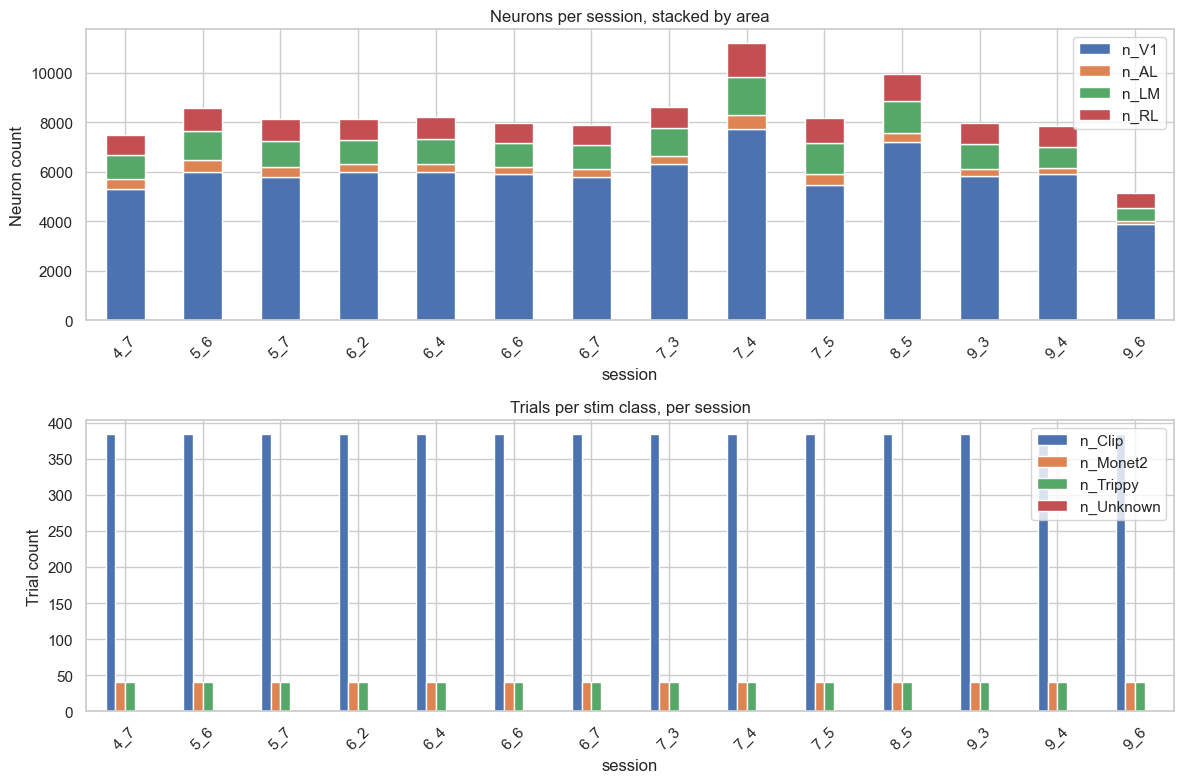

In [5]:
fig, _ = microns_eda.plot_cross_session_overview(summary_df)
fig.savefig(FIGURES_DIR / "1_2_neurons_and_stim_per_session.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Z-score for total neuron count (per-session). Uses ddof=0 (population
# std) to match flag_outlier_sessions, since the 14 sessions are the
# full population we care about, not a sample of a larger pool.
z_n_neurons = (summary_df["n_neurons"] - summary_df["n_neurons"].mean()) / summary_df["n_neurons"].std(ddof=0)

# Per-area percentages: what fraction of each session's neurons are in V1, AL, LM, RL.
area_pct = summary_df[["n_V1", "n_AL", "n_LM", "n_RL"]].div(summary_df["n_neurons"], axis=0) * 100

overview_1_2 = pd.DataFrame({
    "n_neurons": summary_df["n_neurons"],
    "z_n_neurons": z_n_neurons.round(2),
    "% V1": area_pct["n_V1"].round(1),
    "% AL": area_pct["n_AL"].round(1),
    "% LM": area_pct["n_LM"].round(1),
    "% RL": area_pct["n_RL"].round(1),
})
overview_1_2

,n_neurons,z_n_neurons,% V1,% AL,% LM,% RL
session,,,,,,
4_7,7493,-0.59,70.9,5.2,13.1,10.8
5_6,8592,0.28,70.0,5.4,13.5,11.1
5_7,8138,-0.08,71.0,5.0,13.1,11.0
6_2,8158,-0.07,73.6,3.9,12.0,10.6
6_4,8221,-0.02,73.0,3.9,12.5,10.7
6_6,7971,-0.21,74.1,3.6,12.3,10.0
6_7,7887,-0.28,73.6,3.9,12.2,10.3
7_3,8618,0.30,73.2,3.8,13.2,9.9
7_4,11201,2.33,69.0,5.1,13.7,12.2


**Interpretation:**

- **Two sessions are |z| > 2 outliers** in total neuron count (mean ≈ 8241, std ≈ 1270):
  - **9_6** (5130 neurons, z ≈ −2.45) — small field of view.
  - **7_4** (11201 neurons, z ≈ +2.33) — large field of view.
  - **8_5** (9941, z ≈ +1.34) is on the high side but within threshold.

- **Area mix is broadly stable.** V1 dominates (~70% in every session), with LM and RL roughly comparable (~10–14% each) and AL the smallest slice (~3–5%). The recording template — V1-centred with HVA peripheral coverage — is consistent across sessions.

- **9_6 also has the most skewed area composition:** AL drops to ~2.2% of the total (vs ~3–5% elsewhere) and V1 climbs to ~76%. So 9_6 is unusual on both axes — fewer neurons *and* a less balanced area mix.

- **The trial-count plot confirms the table:** every session has the same 384 Clip / 40 Monet2 / 40 Trippy split, no Unknowns. Stimulus structure is identical across sessions.

**Implication:** for **per-session** analyses this is fine. For **pooled** analyses (e.g. concatenating neurons across sessions), 9_6 and 7_4 will weight the average asymmetrically — 7_4 contributes ~2× more neurons than 9_6. If pooling, either subsample to a common count or weight by session. AL-specific analyses should treat 9_6 cautiously given how few AL neurons it contains (115).

### 1.3 Stimulus distribution

The second panel of the figure above shows trial counts by stim class per session.

**What we're spotting:** anomalously many "Unknown" trials in any one session, or skewed Clip/Monet2/Trippy ratios.

**What it means:** labeling issue or different experimental protocol.

**Interpretation:** Stimulus distribution is identical across all 14 sessions: 384 Clip + 40 Monet2 + 40 Trippy + 0 Unknown. No labeling issues, no protocol differences — sessions are directly comparable on the stimulus axis.

### 1.4 Response magnitude distribution

**What we compute:** for each session, per-neuron mean response across all trials → one boxplot per session.

**What we're spotting:** a session whose box is shifted up/down or has unusual spread.

**What it means:** possible imaging-quality issue (calibration drift, photobleaching) — affects any analysis that compares absolute response levels.

**Heads up:** this cell streams every session and takes a few minutes.

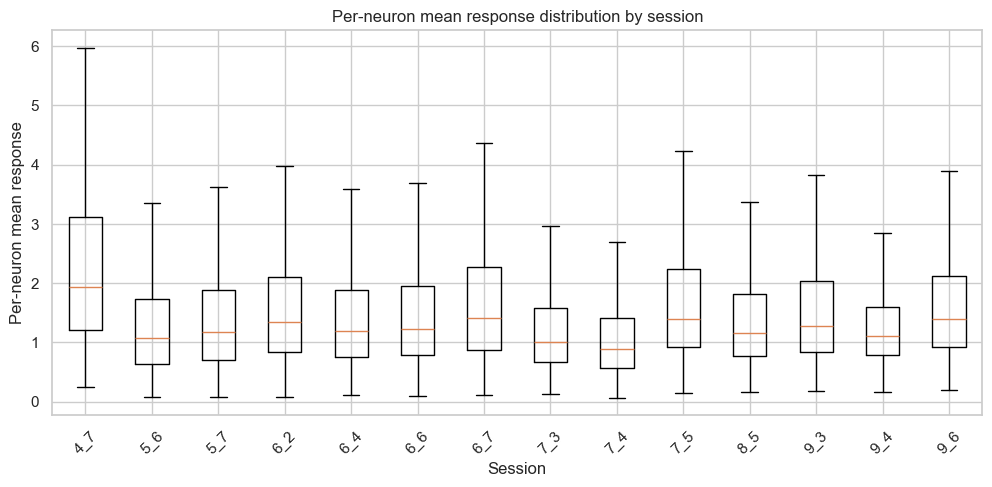

In [7]:
fig, ax = plt.subplots(figsize=(12, 5))
microns_eda.plot_response_magnitude_by_session(reader, DATADIR, ax=ax)
fig.savefig(FIGURES_DIR / "1_4_response_magnitude_by_session.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- **Session 4_7 is clearly shifted up.** Median ≈ 1.95 vs ~1.0–1.4 elsewhere, with the box and whiskers stretched higher (upper whisker ~6 vs ~3–4 for the others). Confirms the flag from previous analysis in 1.1: session 4_7 has systematically larger per-neuron responses, not just a higher median.

- **Sessions 7_4 and 7_3 sit slightly low** (medians ~0.9 and ~1.0, narrower boxes), consistent with their lower variance values in 1.1.

- **The remaining 11 sessions overlap heavily** — medians ~1.05–1.4, similar IQRs and whisker ranges. No sign of calibration drift across the cohort as a whole.

**Implication:** absolute response levels are *not* directly comparable for 4_7 — any analysis using raw magnitudes (e.g. ranking neurons by activity, pooling across sessions) should either exclude 4_7 or z-score per session first. Per-session analyses are unaffected.

### 1.5 Behavioral state per session

**What we compute:** mean pupil diameter and mean treadmill speed, per session.

**What we're spotting:** unusually low pupil (drowsy mouse) or unusually high running (hyperactive).

**What it means:** a major confound for visual cortex — neural activity may be dominated by behavior rather than vision in that session.

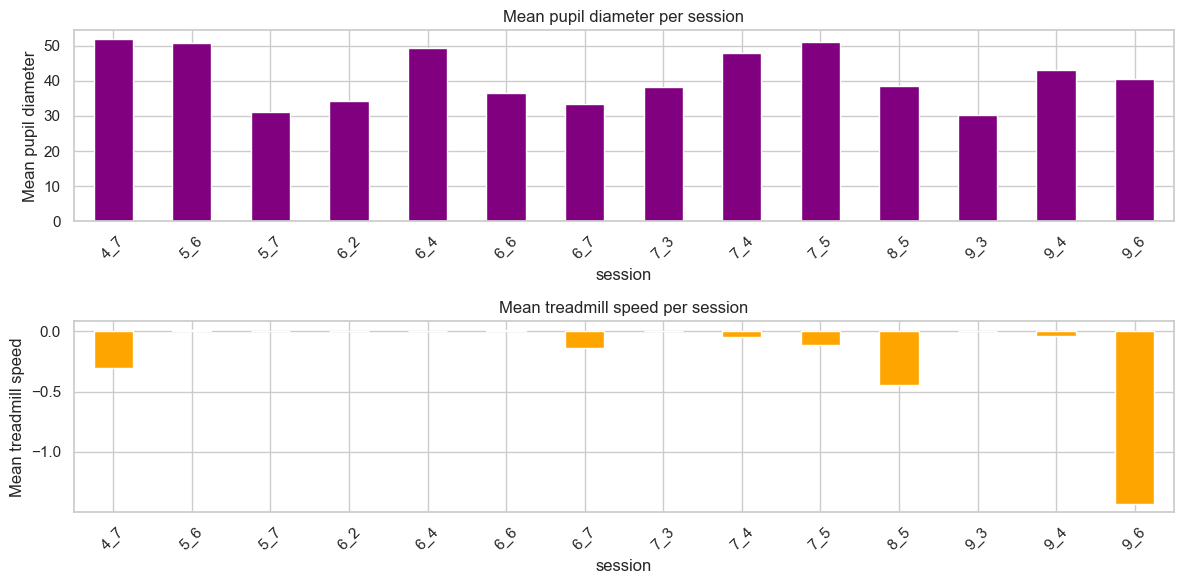

In [8]:
fig, _ = microns_eda.plot_behavior_by_session(summary_df)
fig.savefig(FIGURES_DIR / "1_5_behavior_by_session.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- **Pupil diameter** ranges from ~30 to ~52 across sessions. **9_3 (≈30) and 5_7 (≈31)** are the lowest — possibly drowsier mice, but not dramatically so (still ~60% of the highest). No session looks pathologically low.

- **Treadmill speed** is near zero for most sessions (|speed| < 0.15), confirming mostly stationary mice as expected for head-fixed passive viewing. Three sessions stand out by magnitude:
  - **9_6** (|speed| ≈ 1.43) — by far the most active mouse, ~3× the next-highest. Already flagged in 1.1/1.2; this is the third independent reason to treat 9_6 cautiously.
  - **8_5** (|speed| ≈ 0.45) and **4_7** (|speed| ≈ 0.31) — moderately active, worth noting but not extreme.
  
- **No clear pupil/treadmill coupling** at the session level: 4_7 has both high pupil and moderate movement, but 9_6 (most active) has middling pupil. So behavioural state isn't moving as a single arousal axis here.

**Implication:** **9_6** is the main concern — high movement is a known confound for visual cortex, and running can drive V1 activity independently of the stimulus. For any analysis sensitive to behavioural state (decoding, tuning, noise correlations), either exclude 9_6 or include treadmill speed as a covariate. **8_5** and **4_7** are worth a second look but probably manageable. Low-pupil sessions (5_7, 9_3) are not extreme enough to flag on their own.

### 1.6 Outlier flag table

**What we compute:** z-scores per metric (1.2–1.5) plus a `warning` column listing which metrics each session fails (|z| > 2).

**What we're spotting:** a single place to see which sessions to treat with caution.

In [9]:
flagged = microns_eda.flag_outlier_sessions(summary_df)
microns_eda.plot_outlier_table(flagged)

,n_neurons,n_Unknown,z_n_neurons,z_median_per_neuron_mean,z_mean_pupil_diameter,z_mean_treadmill_speed,z_n_Unknown,warning,is_outlier
session,,,,,,,,,
4_7,7493,0,-0.588691,2.808945,1.417890,-0.345448,0.0,median_per_neuron_mean,True
5_6,8592,0,0.276409,-0.773544,1.268722,0.499965,0.0,,False
5_7,8138,0,-0.080966,-0.317941,-1.328860,0.497149,0.0,,False
6_2,8158,0,-0.065223,0.366682,-0.937328,0.482696,0.0,,False
6_4,8221,0,-0.015631,-0.282534,1.089689,0.492896,0.0,,False
6_6,7971,0,-0.212423,-0.113171,-0.634760,0.508047,0.0,,False
6_7,7887,0,-0.278546,0.631022,-1.045087,0.104722,0.0,,False
7_3,8618,0,0.296875,-1.045529,-0.392627,0.484080,0.0,,False
7_4,11201,0,2.330135,-1.541513,0.904797,0.353821,0.0,n_neurons,True


**Interpretation:**

Three sessions cross the |z|>2 threshold, each consistent with what we already saw upstream:

- **4_7** — `median_per_neuron_mean` (z ≈ +2.81). The high-activity outlier from 1.1 / 1.4. Box was visibly shifted up.
- **7_4** — `n_neurons` (z ≈ +2.33). Largest imaging volume (11,201 neurons). Activity and behaviour are normal.
- **9_6** — `n_neurons` (z ≈ −2.45) **and** `mean_treadmill_speed` (z ≈ −3.37). Smallest imaging volume *and* the most active mouse — flagged on two independent axes, the strongest case for caution.

The remaining 11 sessions, including **7_5**, carry no flags. **7_5** sits near the cohort centre on every axis (|z| ≤ 1.31 across all metrics, neuron count 8,194 vs cohort median 8,176) and looks like a representative session for the deep-dive — no override needed.

## Part 2 — Deep-dive on session `7_5`

Now we move from cross-session statistics to studying one session in depth.

### 2a. Session structure

#### 2a.i Neuron coordinates in 3D

**What we compute:** 3D scatter of every neuron's pial position, colored by area.

**What we're spotting:** V1 forms a coherent spatial cluster, with higher areas (AL/LM/RL) at distinct positions. Outlier: scattered or sparse coverage → field-of-view problem.

In [10]:
deep_meta = microns_eda.get_session_meta(DATADIR, DEEP_DIVE_SESSION)

# Interactive 3D scatter via plotly — drag to rotate, scroll to zoom.
# (A static matplotlib version is also available via
#  microns_eda.plot_neuron_coords_3d if you need a saved figure.)
fig = microns_eda.plot_neuron_coords_3d_interactive(deep_meta)
fig.show()

**Interpretation:**

- **Tangentially the four areas form coherent clusters**: V1 is the large central block, AL/LM/RL surround it at distinct (x, z) locations. Matches expected mouse visual cortex anatomy.
- **The x-z plane shows the acquisition geometry clearly**: data is concentrated in 4 discrete tangential bands with empty space between them. This is *not* missing data — it reflects the multi-field acquisition scheme used by the Baylor functional imaging team, which scans several spatially separated fields simultaneously rather than a continuous volume.
- **Each scan band crosses area boundaries**: V1 dominates the central portions, with AL/LM/RL appearing at the ends of the bands. So every band samples multiple areas, and cross-area comparisons within a session are well-supported.
- **Each band spans ~100–1000 µm in depth**, so all cortical layers are represented within each field. Layer-resolved analyses are viable.
- **No FOV defects**: AL is sparser than the others (matches its low share in the unit table), but coverage is uniform within each scan band.

Session `7_5` is anatomically clean for the deep-dive.

#### 2a.ii Trial timing strip

**What we compute:** one colored bar per trial, in trial order, colored by stim type.

**What we're spotting:** is the design *blocked* (long runs of one stim type) or *interleaved*?

**What it means:** blocked design correlates drift with stim class — a confound for any class-conditioned analysis.

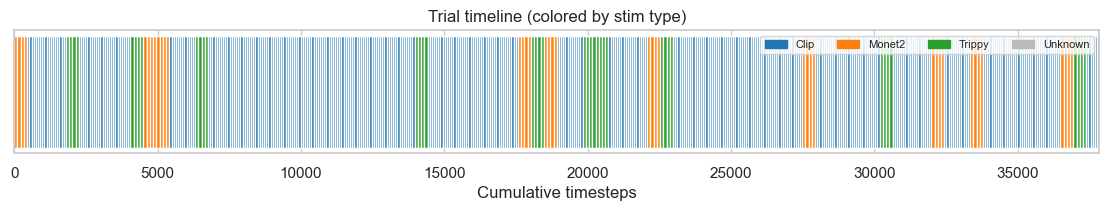

In [11]:
deep_responses, deep_boundaries, deep_stim_types = microns_eda.load_session_responses(
    reader, DATADIR, DEEP_DIVE_SESSION
)
deep_durations = np.diff(deep_boundaries)

fig, ax = plt.subplots(figsize=(14, 1.6))
microns_eda.plot_trial_timeline(deep_stim_types, trial_durations=deep_durations, ax=ax)
fig.savefig(FIGURES_DIR / "2a_ii_trial_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- **Design is interleaved, not blocked.** Monet2 (orange) and Trippy (green) trials appear scattered throughout the session rather than concentrated in dedicated blocks. Clip trials (blue) fill the rest.
- A few short clusters of Monet2 or Trippy trials are visible (e.g. around timesteps ~5000, ~18000, ~22000, ~32000), but these are short bursts on the order of a handful of trials rather than long blocks.
- Total session length spans ~37,000 timesteps (~82 min at 7.5 Hz), consistent with 464 trials of mixed durations.

**Implication:** stim class is decorrelated from time within the session, so any slow drift in neural activity (bleaching, arousal trends) will not systematically bias class-conditioned analyses. Safe to pool trials of the same class across the session.

#### 2a.iii Trial duration histogram

**What we compute:** histogram of trial lengths in timesteps.

**What we're spotting:** the expected bimodal distribution at 75 (Clip) and 113 (Monet2/Trippy) timesteps.

**What it means:** any time-domain analysis (PSTH, trajectories) must handle variable trial length.

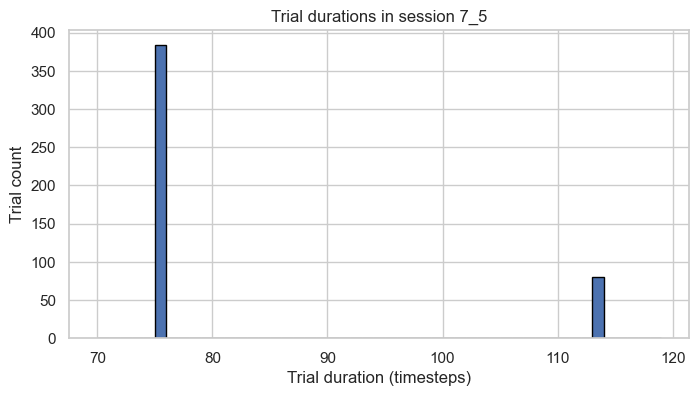

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(deep_durations, bins=np.arange(70, 120, 1), edgecolor="black")
ax.set_xlabel("Trial duration (timesteps)")
ax.set_ylabel("Trial count")
ax.set_title(f"Trial durations in session {DEEP_DIVE_SESSION}")
fig.savefig(FIGURES_DIR / "2a_iii_trial_durations.png", dpi=150, bbox_inches="tight")
plt.show()

**Interpretation:**

- Bimodal distribution as expected: ~384 trials at 75 timesteps (Clip, ~10 s) and ~80 trials at 113 timesteps (Monet2 + Trippy, ~15 s). Counts match the stim breakdown from 1.1 (384 + 40 + 40 = 464).
- Each peak is a single tight bar — no jitter within a class, all trials of the same type have identical length.

**Implication:** time-aligned analyses (PSTH, trajectories, decoding over time) must either restrict to one stim class at a time or truncate to a common 75-timestep window. Cannot stack trials of mixed duration into a single matrix.

### 2b. Stimulus catalog

#### 2b.i Sample frames per stim class

**What we compute:** the middle frame of one example clip from each of `Clip`, `Monet2`, `Trippy`.

**What we're spotting:** intuition for what the mouse saw, and the visual difference between classes.

In [ ]:
deep_stim_map = microns_eda.build_stim_type_map(reader, DEEP_DIVE_SESSION)
fig = microns_eda.plot_stim_examples(reader, deep_stim_map)
fig.savefig(FIGURES_DIR / "2b_i_stim_examples.png", dpi=150, bbox_inches="tight")
plt.show()

#### 2b.ii Investigating "Unknown" trials

**What we compute:** for the first few "Unknown" hashes in this session, ask the reader what the underlying type is and whether the hash exists in `/types/` or `/videos/` of the H5.

**What we're spotting:** any pattern that lets us *recover* the type, *treat as a 4th class*, or *drop cleanly*.

In [ ]:
unknown_hashes = [h for h, t in deep_stim_map.items() if t == "Unknown"]
print(f"Total 'Unknown' hashes in session {DEEP_DIVE_SESSION}: {len(unknown_hashes)}")

with microns_eda.open_h5(DATADIR) as f:
    types_keys = set(f["types"].keys())
    video_keys = set(f["videos"].keys())
    for h in unknown_hashes[:5]:
        in_types = any(h in f["types"][k] for k in types_keys)
        in_videos = h in video_keys
        # Library may expose alternate encoding; cross-check.
        try:
            via_reader = reader.get_video_type(h)
        except Exception as e:
            via_reader = f"reader error: {e!s}"
        print(f"  hash={h!r}  in_types={in_types}  in_videos={in_videos}  reader_type={via_reader!r}")

**Interpretation (fill in after running):** _Decide on a treatment for the 24% Unknown trials: recover, keep as 4th class, or drop._